# Finite-Shot Device Preflight and Circuit Audit

This tutorial follows one finite FABLE QSVT circuit through local device preflight, logical and decomposed circuit auditing, finite-shot execution, and comparison with an ideal statevector reference. The device is PennyLane's credential-free `default.qubit` simulator; no provider job is submitted.

Goals:

- make the caller-supplied device and state-preparation contract explicit
- inspect preflight compatibility before execution
- compare logical and locally decomposed operation ledgers
- interpret finite-shot probabilities and sampling uncertainty against an ideal reference

## Variable definitions

- $A=\operatorname{diag}(0.2,0.8)$ is the logical matrix and $\alpha=1.6$ normalizes the FABLE block encoding of $A/\alpha$.
- $x\in[-1,1]$ is the normalized signal value and $P(x)=x$ is the identity polynomial.
- $X$ is the Pauli-$X$ gate used to prepare logical basis state $|1\rangle$; `encoding_wires` is the ordered circuit register.
- $N$ (`SHOTS`) is the sample count and $p$ a measured probability, giving binomial standard-error proxy $\sqrt{p(1-p)/N}$.

## Notebook guide

- **Learning objective:** preflight, audit, and execute a finite-shot local circuit.
- **Prerequisites:** an editable repository install plus basic NumPy and linear-algebra familiarity.
- **Estimated runtime:** about 3–5 minutes on a local CPU.
- **Navigation:** [collection index](README.md) · [previous](19_Accuracy_Driven_QSVT_Planning.ipynb).


## Truth contract

This is finite simulator execution on a caller-created PennyLane device. It validates local circuit construction, decomposition, finite-shot probability measurement, and agreement with an ideal finite reference. It does not claim real-hardware execution, scalable data access, provider-native compilation, calibration capture, mitigation, fault tolerance, or quantum advantage.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml

from notebooks._support import display_table
from qsvt.block_encoding import matrix_block_encoding_spec
from qsvt.execution import execute_qsvt_from_spec
from qsvt.hardware import (
    execute_qsvt_on_device,
    qsvt_hardware_circuit_report,
    qsvt_hardware_preflight,
)


## Block encoding, preparation, and local device

FABLE is selected because this small matrix satisfies its entrywise normalization condition and has an explicit PennyLane decomposition path. The preparation function uses an elementary gate rather than `StatePrep`, matching the hardware-oriented helper's conservative default contract.


In [2]:
SEED = 0
SHOTS = 2000
matrix = np.diag([0.2, 0.8])
alpha = 1.6
poly = np.array([0.0, 1.0])
spec = matrix_block_encoding_spec(
    matrix,
    alpha=alpha,
    block_encoding="fable",
)

def prepare_basis_one() -> None:
    qml.PauliX(spec.encoding_wires[-1])

device = qml.device(
    "default.qubit",
    wires=spec.encoding_wires,
    seed=SEED,
)
print(f"encoding wires: {spec.encoding_wires}")
print(f"block-encoding method: {spec.block_encoding}")
print(f"normalization alpha: {spec.alpha}")


encoding wires: (0, 1, 2)
block-encoding method: fable
normalization alpha: 1.6


## Preflight before execution

Preflight constructs the intended logical tape and checks the finite-shot request, wire coverage, preparation style, advertised operation support, and measurement support. Unknown device capabilities remain explicit rather than being mistaken for native-provider validation.


In [3]:
preflight = qsvt_hardware_preflight(
    spec,
    poly,
    prepare_basis_one,
    device,
    shots=SHOTS,
)
preflight_rows = [
    {"check": name, "passed": passed}
    for name, passed in preflight.checks.items()
]
display_table(
    "Local device preflight",
    preflight_rows,
    [
        ("check", lambda row: row["check"]),
        ("passed", lambda row: row["passed"]),
    ],
    layout="rows",
)
print(f"logical operations: {preflight.operation_names}")
print(f"measurements: {preflight.measurement_names}")


Local device preflight
----------------------
check                              passed
---------------------------------  ------
finite_shots                       True  
device_wires_cover_circuit         True  
preparation_is_callable            True  
shots_within_device_limits         True  
stateprep_allowed                  True  
operations_supported_when_known    True  
measurements_supported_when_known  True  
logical operations: ('PauliX', 'QSVT')
measurements: ('ProbabilityMP',)


## Logical and decomposed circuit audit

The audit uses the same specification, polynomial, preparation, device, and shot contract as execution. It does not run the circuit. The logical tape contains the high-level `QSVT` operation; one level of PennyLane decomposition exposes projector phases and the FABLE signal operation while preserving any remaining backend-level primitives.


In [4]:
circuit_audit = qsvt_hardware_circuit_report(
    spec,
    poly,
    prepare_basis_one,
    device,
    shots=SHOTS,
)
audit_rows = [
    {
        "level": "logical",
        "gates": circuit_audit.logical_resource_summary["num_gates"],
        "operations": circuit_audit.logical_operations,
        "unsupported": circuit_audit.unsupported_logical_operations,
    },
    {
        "level": "decomposed",
        "gates": circuit_audit.decomposed_resource_summary["num_gates"],
        "operations": circuit_audit.decomposed_operations,
        "unsupported": circuit_audit.unsupported_decomposed_operations,
    },
]
display_table(
    "Circuit audit",
    audit_rows,
    [
        ("level", lambda row: row["level"]),
        ("gate count", lambda row: row["gates"]),
        ("operations", lambda row: row["operations"]),
        ("unsupported", lambda row: row["unsupported"]),
    ],
    layout="rows",
)
print(f"decomposition status: {circuit_audit.decomposition_status}")
print(f"executed by audit: {circuit_audit.as_report()['executed']}")


Circuit audit
-------------
level       gate count  operations                                unsupported
----------  ----------  ----------------------------------------  -----------
logical     2           PauliX, QSVT                                         
decomposed  5           RX, GlobalPhase, PCPhase, FABLE, PCPhase             
decomposition status: succeeded
executed by audit: False


## Finite-shot execution and ideal reference

The device-facing helper executes full-register probabilities and extracts the logical signal-subspace probabilities. The ideal executor supplies the corresponding finite statevector reference. Error bars below use the usual binomial standard-error proxy $\sqrt{p(1-p)/N}$ for each displayed probability; the execution report separately records success-probability and maximum full-register uncertainties.


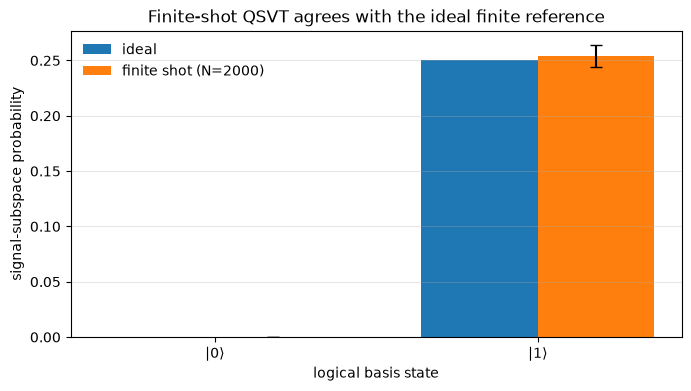

Finite-shot comparison
----------------------
metric                        sampled  ideal/reference
----------------------------  -------  ---------------
logical success probability   0.254    0.25           
logical probability L2 error  0.004    0              
reported success standard error: 0.0097


In [5]:
sampled = execute_qsvt_on_device(
    spec,
    poly,
    prepare_basis_one,
    device,
    shots=SHOTS,
)
ideal = execute_qsvt_from_spec(spec, poly, [0.0, 1.0])
assert sampled.logical_probabilities is not None
assert ideal.logical_probabilities is not None

sampled_probabilities = sampled.logical_probabilities
ideal_probabilities = ideal.logical_probabilities
sampling_errors = np.sqrt(
    np.clip(sampled_probabilities * (1.0 - sampled_probabilities), 0.0, None)
    / SHOTS
)
probability_l2_error = float(
    np.linalg.norm(sampled_probabilities - ideal_probabilities)
)

basis = np.arange(sampled_probabilities.size)
fig, ax = plt.subplots(figsize=(6.8, 3.8), constrained_layout=True)
ax.bar(basis - 0.18, ideal_probabilities, width=0.36, label="ideal")
ax.bar(
    basis + 0.18,
    sampled_probabilities,
    width=0.36,
    yerr=sampling_errors,
    capsize=4,
    label=f"finite shot (N={SHOTS})",
)
ax.set_xticks(basis, [f"|{index}⟩" for index in basis])
ax.set_xlabel("logical basis state")
ax.set_ylabel("signal-subspace probability")
ax.set_title("Finite-shot QSVT agrees with the ideal finite reference")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
plt.show()

comparison_rows = [
    {
        "metric": "logical success probability",
        "sampled": sampled.logical_success_probability,
        "ideal": ideal.logical_success_probability,
    },
    {
        "metric": "logical probability L2 error",
        "sampled": probability_l2_error,
        "ideal": 0.0,
    },
]
display_table(
    "Finite-shot comparison",
    comparison_rows,
    [
        ("metric", lambda row: row["metric"]),
        ("sampled", lambda row: row["sampled"]),
        ("ideal/reference", lambda row: row["ideal"]),
    ],
    layout="rows",
)
print(f"reported success standard error: {sampled.logical_success_standard_error:.4f}")


## Validation

These checks ensure preflight passes, the audit remains non-executing, decomposition exposes a deeper operation ledger, finite-shot execution succeeds, and the seeded sample stays within the stated agreement tolerance.


In [6]:
assert preflight.passed
assert all(preflight.checks.values())
assert circuit_audit.as_report()["executed"] is False
assert circuit_audit.decomposition_status == "succeeded"
assert "QSVT" in circuit_audit.logical_operations
assert circuit_audit.decomposed_resource_summary["num_gates"] > circuit_audit.logical_resource_summary["num_gates"]
assert sampled.succeeded and ideal.succeeded
assert sampled.logical_success_standard_error is not None
assert probability_l2_error < 0.08
assert circuit_audit.provider_plugin.provider_name is None
print("validation: passed")


validation: passed


## Takeaways and next steps

- **Result:** The workflow shows how to preflight, audit, and execute a finite-shot local circuit.
- **Interpretation boundary:** Treat simulator-scale circuits and resource proxies according to the truth contract stated in the notebook.
- **Continue:** [collection index](README.md) · [previous](19_Accuracy_Driven_QSVT_Planning.ipynb).
